# Adult Census Income Prediction — Industry-Grade ML & DL Project
### Predicting whether an individual's annual income exceeds $50K, using US Census data

**Dataset:** UCI Adult / Census Income Dataset (45,174 real records after cleaning, 14 features)
**Goal:** Binary Classification (`<=50K` vs `>50K`)
**Pipeline:** EDA → Preprocessing → Classical ML Models → Deep Learning (Neural Network) → Model Comparison → Save Best Model → Production Prediction Check

---


## 1. Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1785725291.853764     654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785725291.854848     654 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785725292.770447     654 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785725296.277305     654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785725296.279430     654 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## 2. Load Dataset

In [2]:

df = pd.read_csv('adult_income_full.csv')
print("Shape:", df.shape)
df.head()


Shape: (45174, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45174 entries, 0 to 45173
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45174 non-null  int64
 1   workclass       45174 non-null  str  
 2   fnlwgt          45174 non-null  int64
 3   education       45174 non-null  str  
 4   education_num   45174 non-null  int64
 5   marital_status  45174 non-null  str  
 6   occupation      45174 non-null  str  
 7   relationship    45174 non-null  str  
 8   race            45174 non-null  str  
 9   sex             45174 non-null  str  
 10  capital_gain    45174 non-null  int64
 11  capital_loss    45174 non-null  int64
 12  hours_per_week  45174 non-null  int64
 13  native_country  45174 non-null  str  
 14  income          45174 non-null  str  
dtypes: int64(6), str(9)
memory usage: 8.6 MB


In [4]:

df.describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,45174.000000,4.517400e+04,45174.000000,45174.000000,45174.000000,45174.000000
mean,38.556471,1.897380e+05,10.119383,1102.600677,88.689556,40.942533
std,13.215341,1.056535e+05,2.551726,7510.331212,405.160881,12.007862
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173922e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783120e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379030e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## 3. Exploratory Data Analysis (EDA)
Complete graphical analysis of the dataset before modeling.

### 3.1 Target Variable Distribution

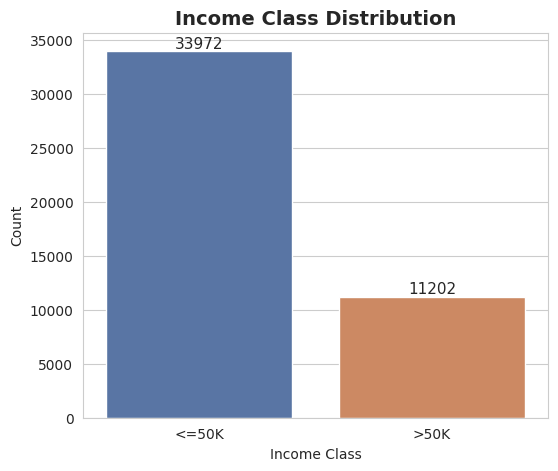

income
<=50K    75.20255
>50K     24.79745
Name: proportion, dtype: float64


In [5]:

plt.figure(figsize=(6,5))
ax = sns.countplot(x='income', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Income Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Income Class')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.savefig('outputs/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(df['income'].value_counts(normalize=True) * 100)


### 3.2 Missing Values Check

In [6]:

missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values remaining (already cleaned).")


No missing values remaining (already cleaned).


### 3.3 Numerical Feature Distributions

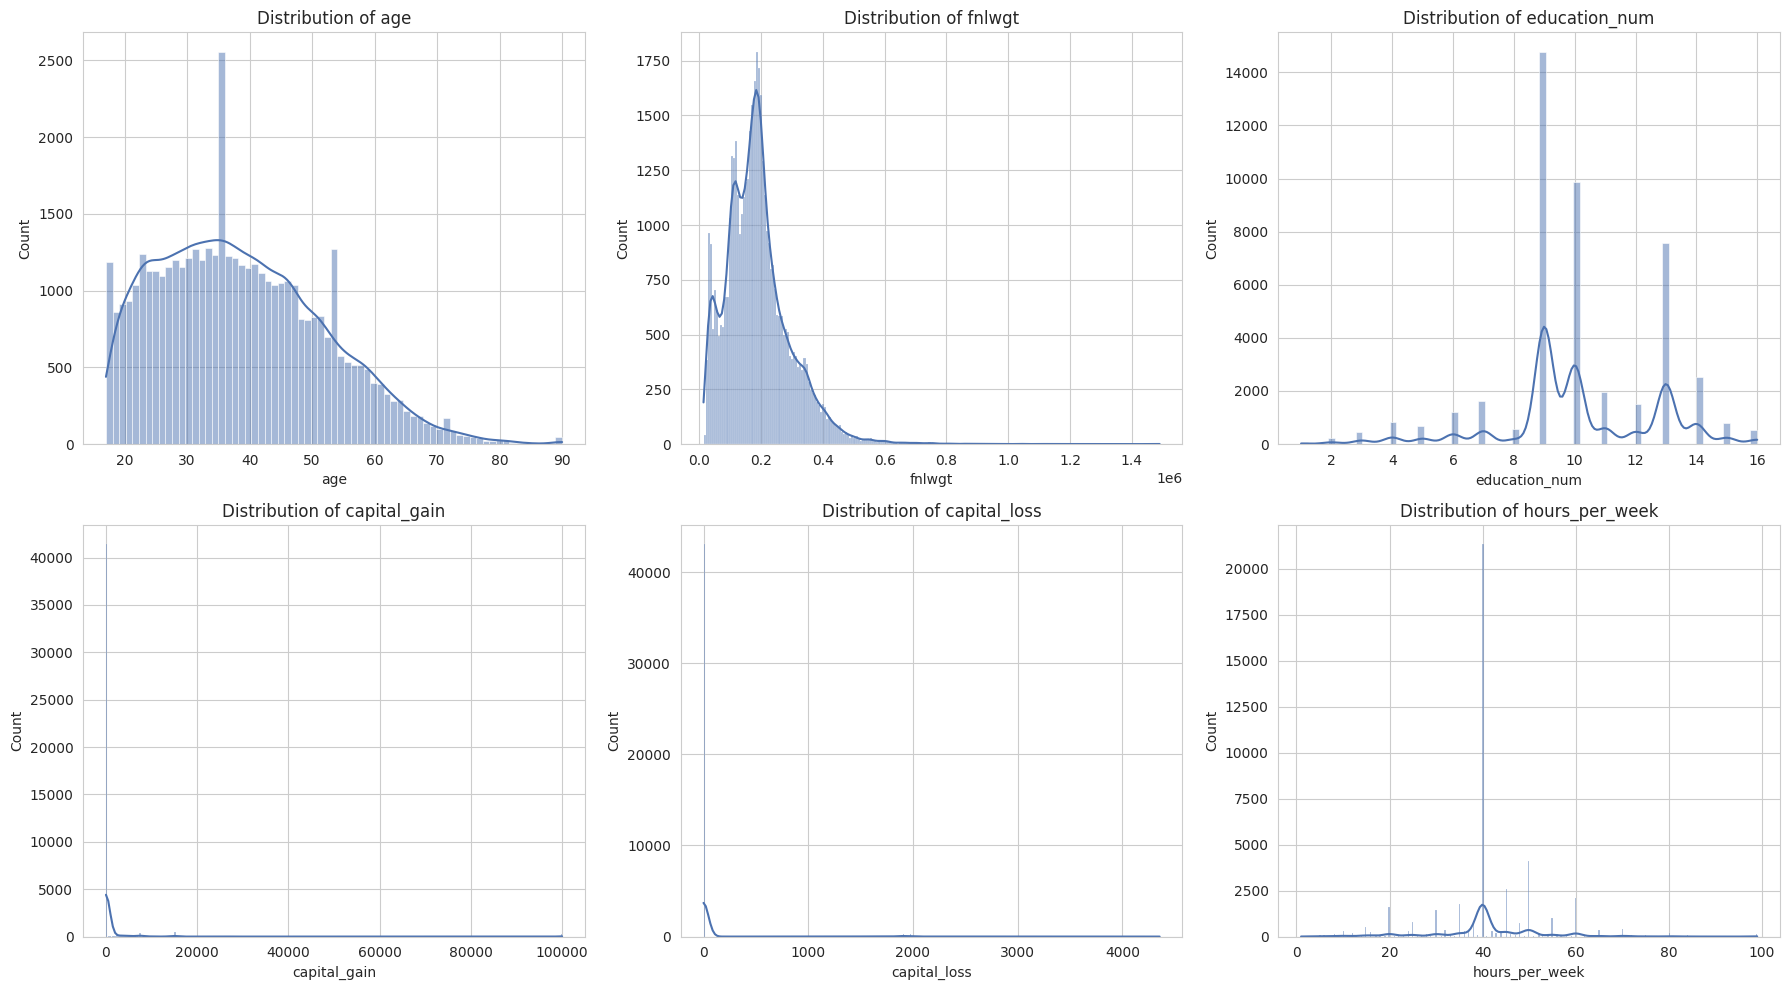

In [7]:

num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('outputs/numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.4 Age & Hours-per-Week vs Income

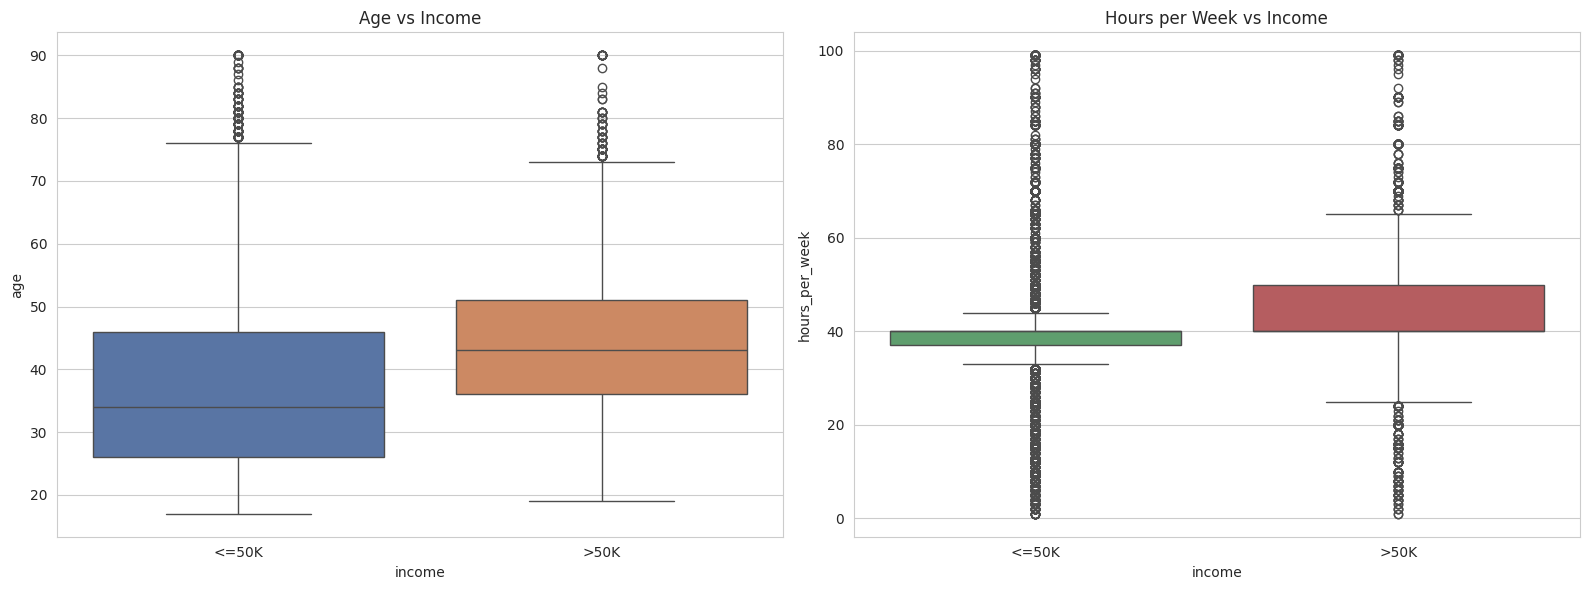

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x='income', y='age', data=df, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Age vs Income')
sns.boxplot(x='income', y='hours_per_week', data=df, ax=axes[1], palette=['#55A868','#C44E52'])
axes[1].set_title('Hours per Week vs Income')
plt.tight_layout()
plt.savefig('outputs/age_hours_vs_income.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.5 Categorical Features vs Income

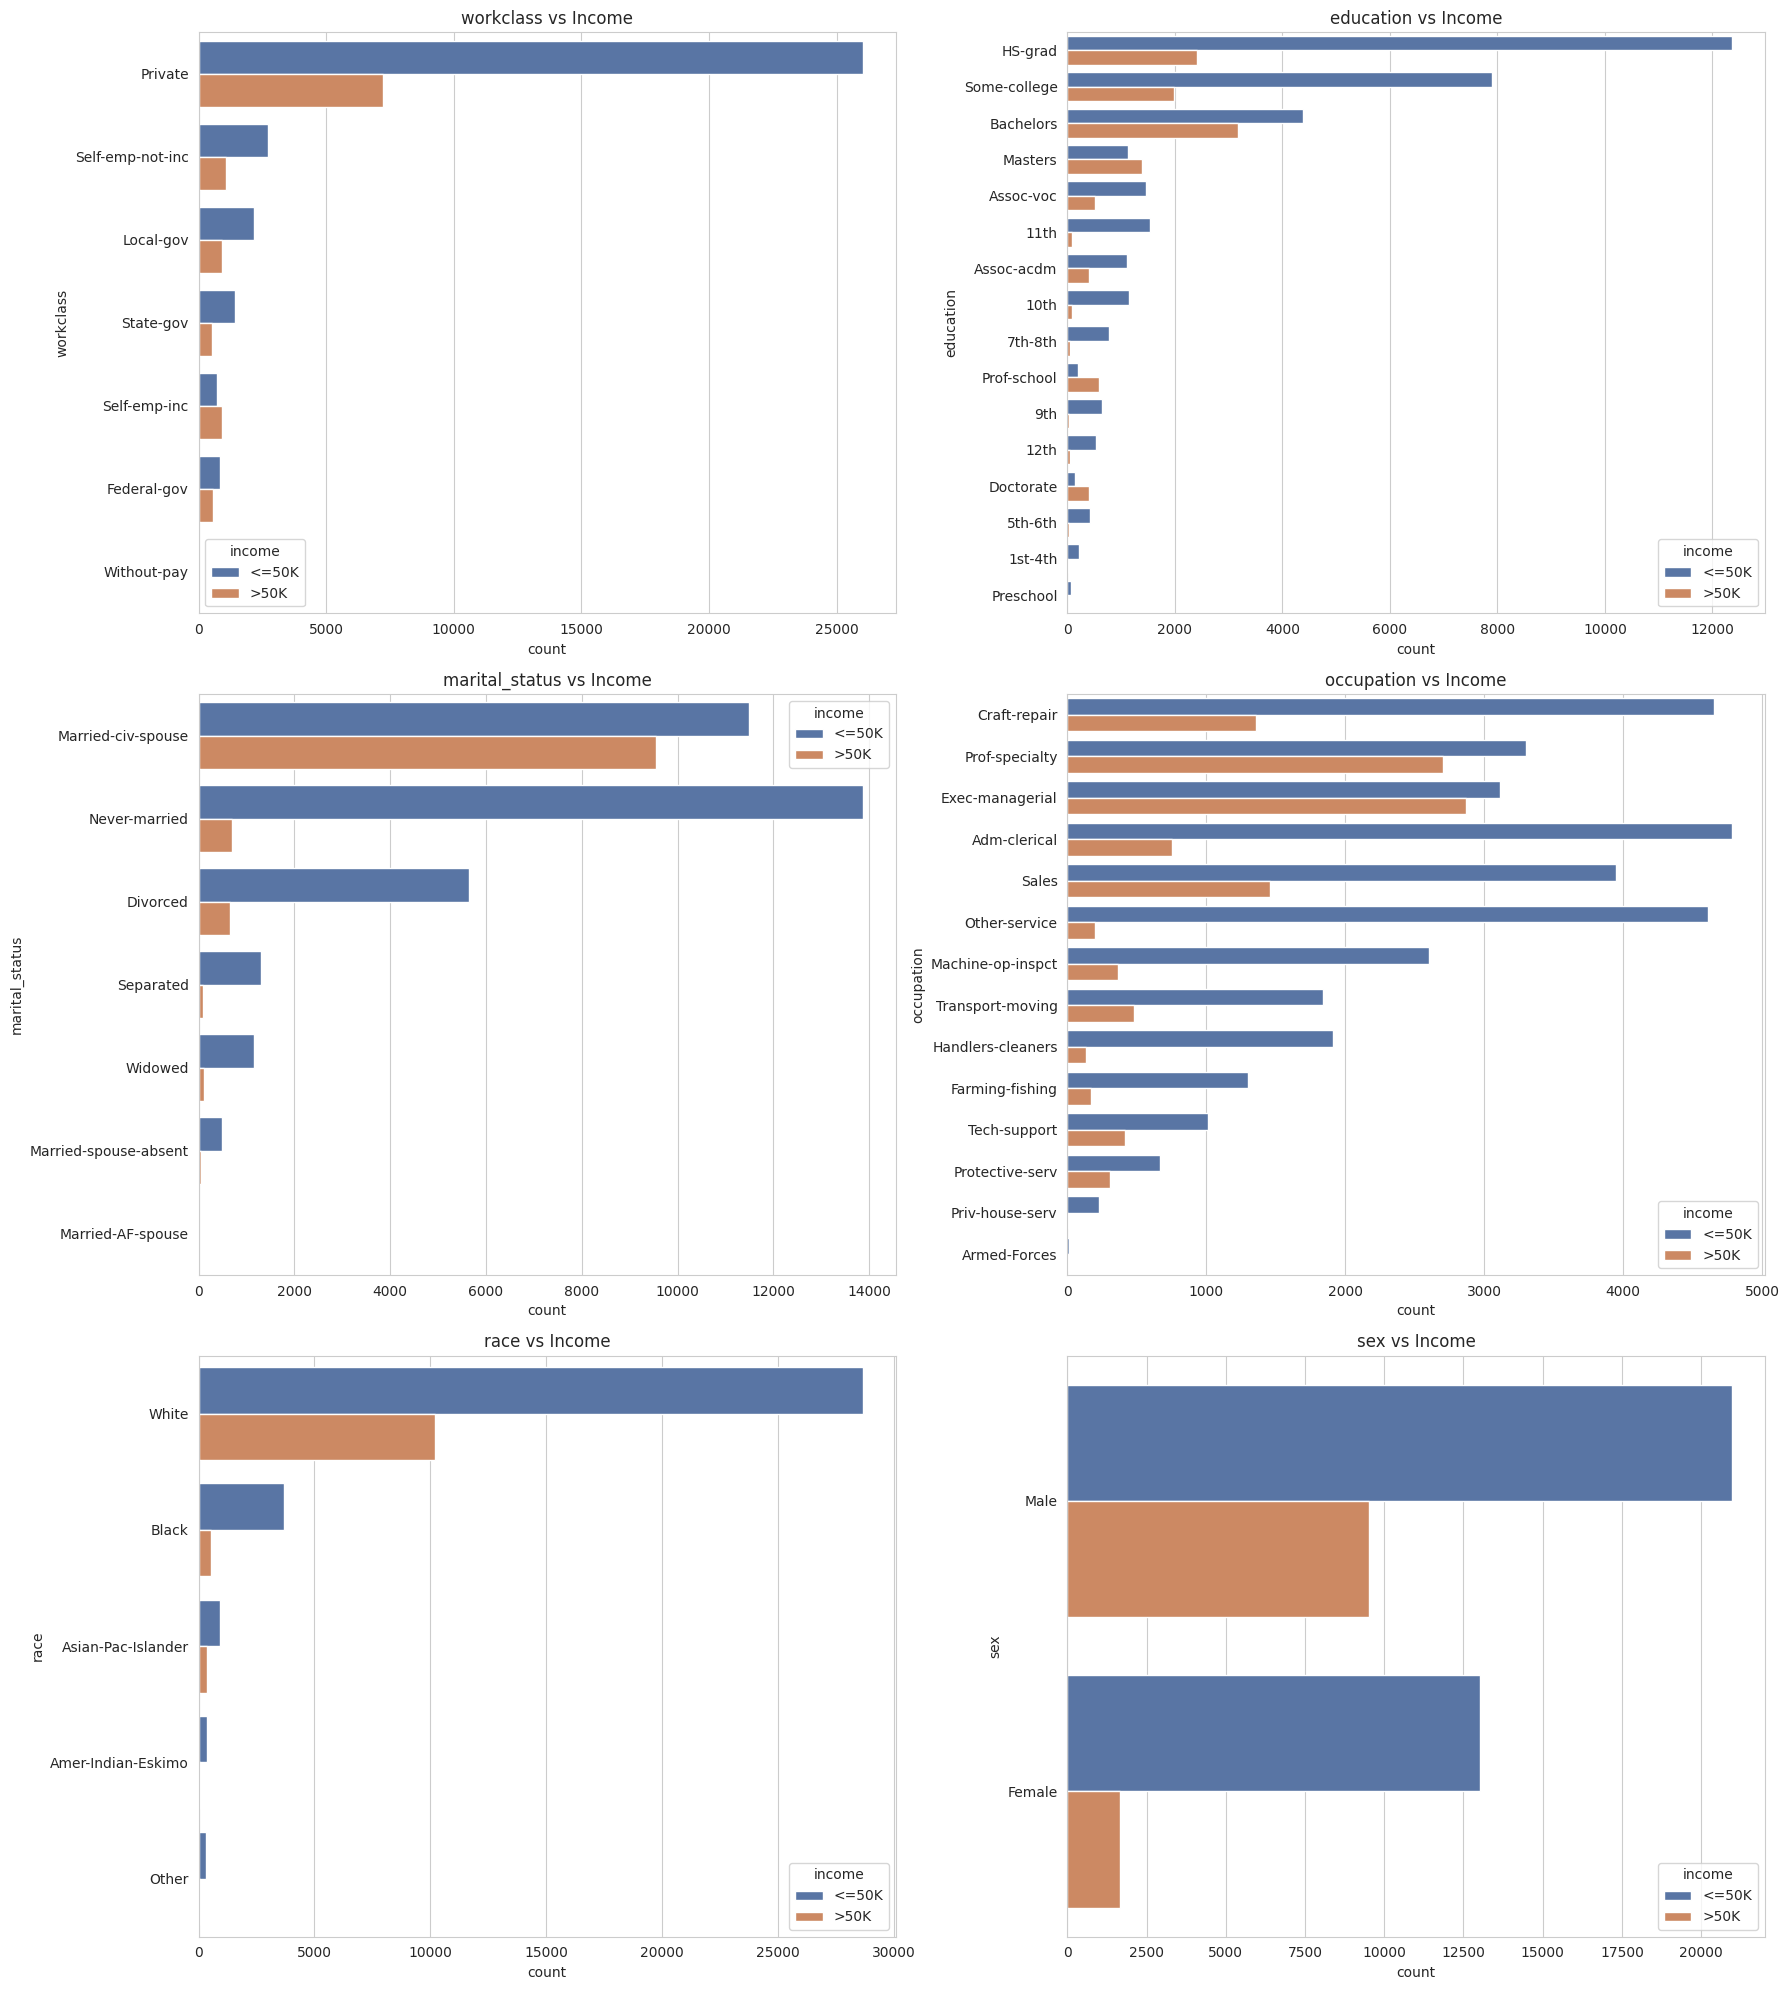

In [9]:

cat_cols = ['workclass', 'education', 'marital_status', 'occupation', 'race', 'sex']

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
for i, col in enumerate(cat_cols):
    ax = axes[i//2, i%2]
    order = df[col].value_counts().index
    sns.countplot(y=col, hue='income', data=df, ax=ax, order=order, palette=['#4C72B0','#DD8452'])
    ax.set_title(f'{col} vs Income')
plt.tight_layout()
plt.savefig('outputs/categorical_vs_income.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.6 Correlation Heatmap (Numerical Features)

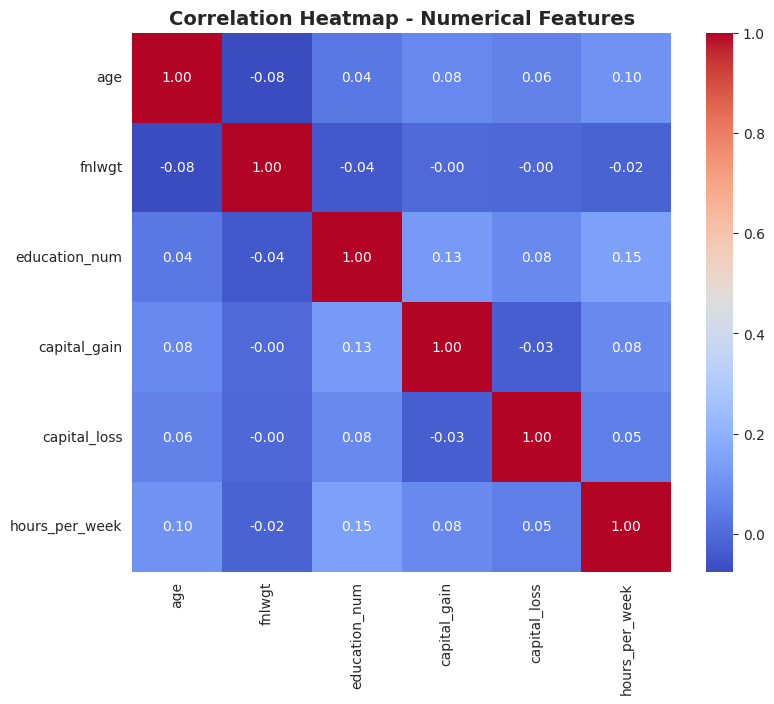

In [10]:

plt.figure(figsize=(9,7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.savefig('outputs/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.7 Sex & Race Distribution

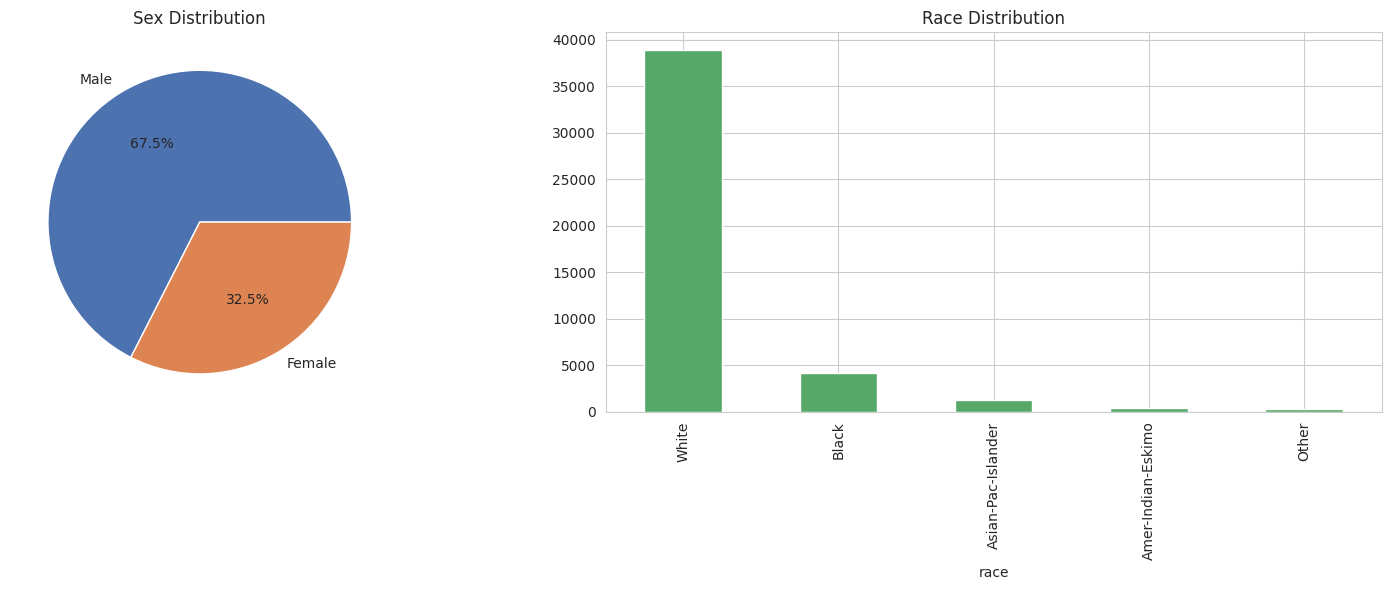

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16,6))
df['sex'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=['#4C72B0','#DD8452'])
axes[0].set_title('Sex Distribution')
axes[0].set_ylabel('')
df['race'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Race Distribution')
plt.tight_layout()
plt.savefig('outputs/sex_race_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing
- Encode categorical variables
- Encode target
- Scale numerical features
- Train / Test split (stratified)

In [12]:

data = df.copy()

target_le = LabelEncoder()
data['income'] = target_le.fit_transform(data['income'])   # <=50K -> 0, >50K -> 1
print("Target classes:", dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

categorical_cols = ['workclass', 'education', 'marital_status', 'occupation',
                     'relationship', 'race', 'sex', 'native_country']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

X = data.drop('income', axis=1)
y = data['income']

feature_names = list(X.columns)
print("Features:", feature_names)


Target classes: {'<=50K': np.int64(0), '>50K': np.int64(1)}
Features: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']


In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (36139, 14)  Test shape: (9035, 14)


## 5. Classical Machine Learning Models
We train 3 industry-standard classifiers: Logistic Regression, Random Forest, and XGBoost.

In [14]:

results = {}

def evaluate_model(name, model, X_te, y_te, y_pred, y_prob):
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=['<=50K', '>50K']))
    return results[name]


### 5.1 Logistic Regression

In [15]:

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test, y_pred_lr, y_prob_lr)


--- Logistic Regression ---
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      6795
        >50K       0.72      0.46      0.56      2240

    accuracy                           0.82      9035
   macro avg       0.78      0.70      0.72      9035
weighted avg       0.81      0.82      0.81      9035



{'accuracy': 0.8219147758716104,
 'precision': 0.7207837648705389,
 'recall': 0.45982142857142855,
 'f1': 0.5614608885254838,
 'roc_auc': 0.8444935548722801}

### 5.2 Random Forest

In [16]:

rf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Random Forest', rf, X_test_scaled, y_test, y_pred_rf, y_prob_rf)


--- Random Forest ---
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      6795
        >50K       0.79      0.58      0.67      2240

    accuracy                           0.86      9035
   macro avg       0.83      0.77      0.79      9035
weighted avg       0.85      0.86      0.85      9035



{'accuracy': 0.8582180409518539,
 'precision': 0.7897280966767372,
 'recall': 0.5834821428571428,
 'f1': 0.6711168164313223,
 'roc_auc': 0.9145061363397455}

### 5.3 XGBoost

In [17]:

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                     random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
evaluate_model('XGBoost', xgb, X_test_scaled, y_test, y_pred_xgb, y_prob_xgb)


--- XGBoost ---
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      6795
        >50K       0.77      0.65      0.70      2240

    accuracy                           0.86      9035
   macro avg       0.83      0.79      0.81      9035
weighted avg       0.86      0.86      0.86      9035



{'accuracy': 0.8644161593801881,
 'precision': 0.7695167286245354,
 'recall': 0.646875,
 'f1': 0.7028862478777589,
 'roc_auc': 0.9254510932408283}

### 5.4 Feature Importance (Random Forest & XGBoost)

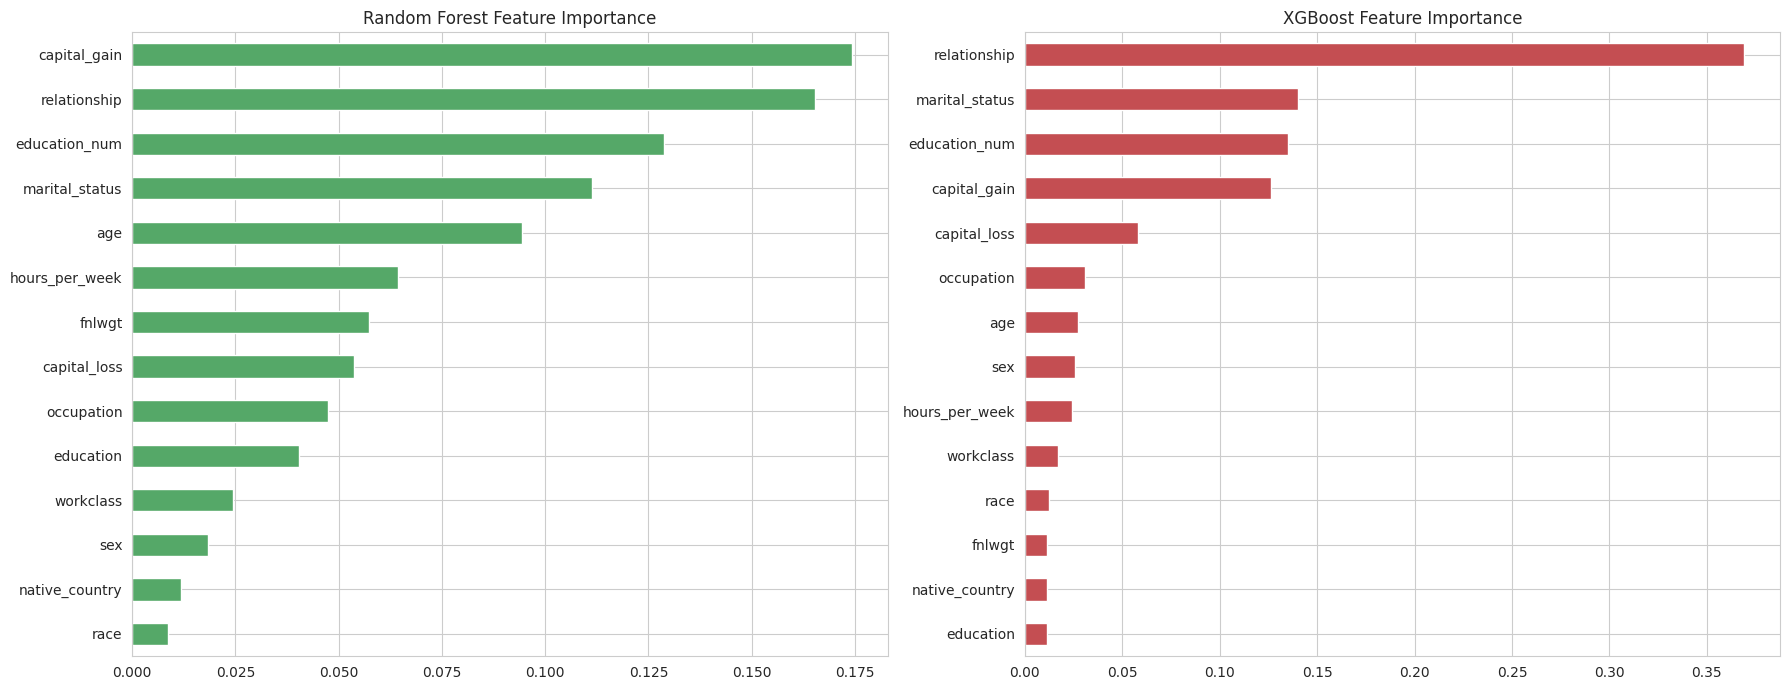

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Random Forest Feature Importance')

xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Deep Learning Model — Artificial Neural Network (Keras)
A fully-connected feed-forward neural network with Batch Normalization and Dropout for regularization.

In [19]:

n_features = X_train_scaled.shape[1]

dl_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

dl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

dl_model.summary()


E0000 00:00:1785725325.039102     654 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [20]:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
)

history = dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100


  1/120 ━━━━━━━━━━━━━━━━━━━━ 5:21 3s/step - accuracy: 0.7461 - auc: 0.5377 - loss: 0.6432

 12/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7419 - auc: 0.6359 - loss: 0.5878 

 25/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7598 - auc: 0.7175 - loss: 0.5236

 38/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7747 - auc: 0.7496 - loss: 0.4942

...

 73/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8492 - auc: 0.9079 - loss: 0.3178

 87/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8485 - auc: 0.9077 - loss: 0.3185

100/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8489 - auc: 0.9078 - loss: 0.3189

114/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8487 - auc: 0.9084 - loss: 0.3182

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8490 - auc: 0.9079 - loss: 0.3189 - val_accuracy: 0.8528 - val_auc: 0.9110 - val_loss: 0.3160 - learning_rate: 6.2500e-05


### 6.1 Training History (Loss & Accuracy Curves)

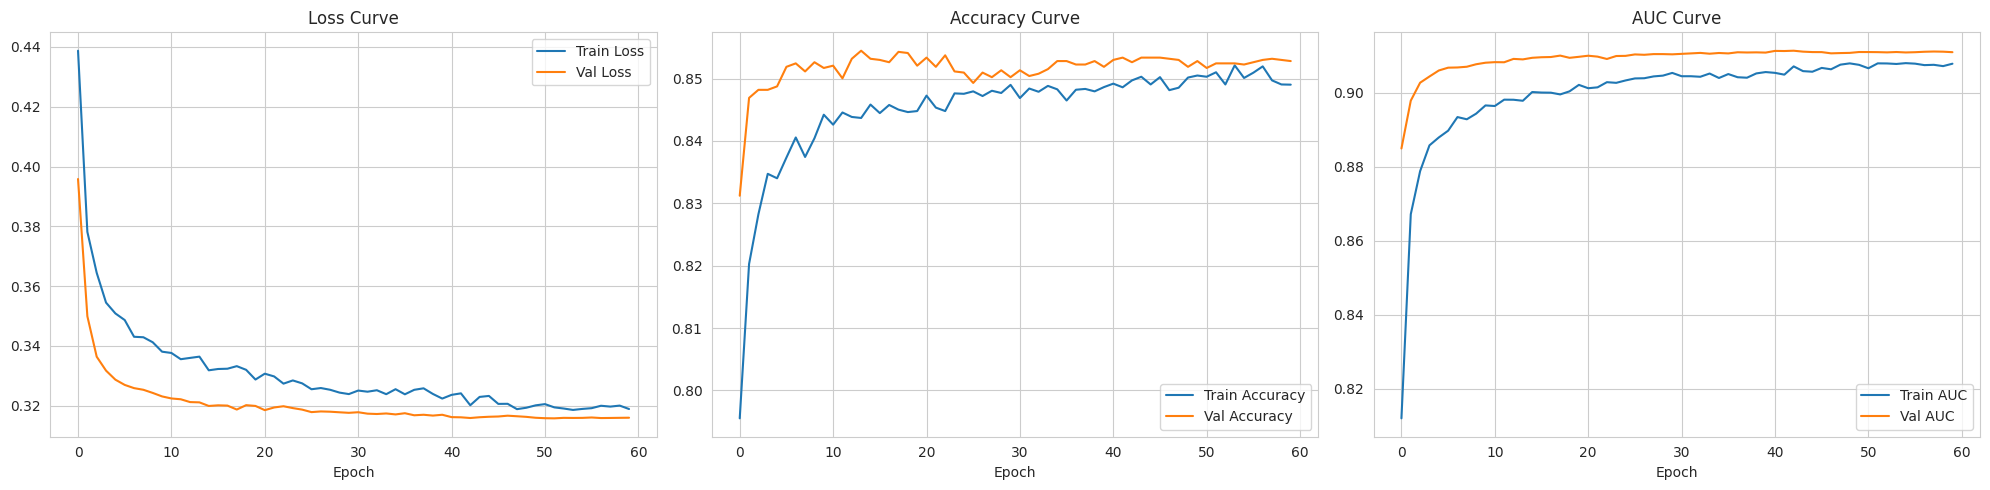

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC Curve')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/dl_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


### 6.2 Neural Network Evaluation

In [22]:

y_prob_dl = dl_model.predict(X_test_scaled).flatten()
y_pred_dl = (y_prob_dl >= 0.5).astype(int)
evaluate_model('Deep Neural Network', dl_model, X_test_scaled, y_test, y_pred_dl, y_prob_dl)


  1/283 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step

 44/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   

 85/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

127/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

168/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

253/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


--- Deep Neural Network ---
              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      6795
        >50K       0.72      0.59      0.65      2240

    accuracy                           0.84      9035
   macro avg       0.80      0.76      0.77      9035
weighted avg       0.83      0.84      0.84      9035



{'accuracy': 0.8411732152739347,
 'precision': 0.7205479452054795,
 'recall': 0.5870535714285714,
 'f1': 0.6469864698646987,
 'roc_auc': 0.9008298184063912}

## 7. Model Comparison — ML vs DL

In [23]:

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('roc_auc', ascending=False)
print(results_df)


                     accuracy  precision    recall        f1   roc_auc
XGBoost              0.864416   0.769517  0.646875  0.702886  0.925451
Random Forest        0.858218   0.789728  0.583482  0.671117  0.914506
Deep Neural Network  0.841173   0.720548  0.587054  0.646986  0.900830
Logistic Regression  0.821915   0.720784  0.459821  0.561461  0.844494


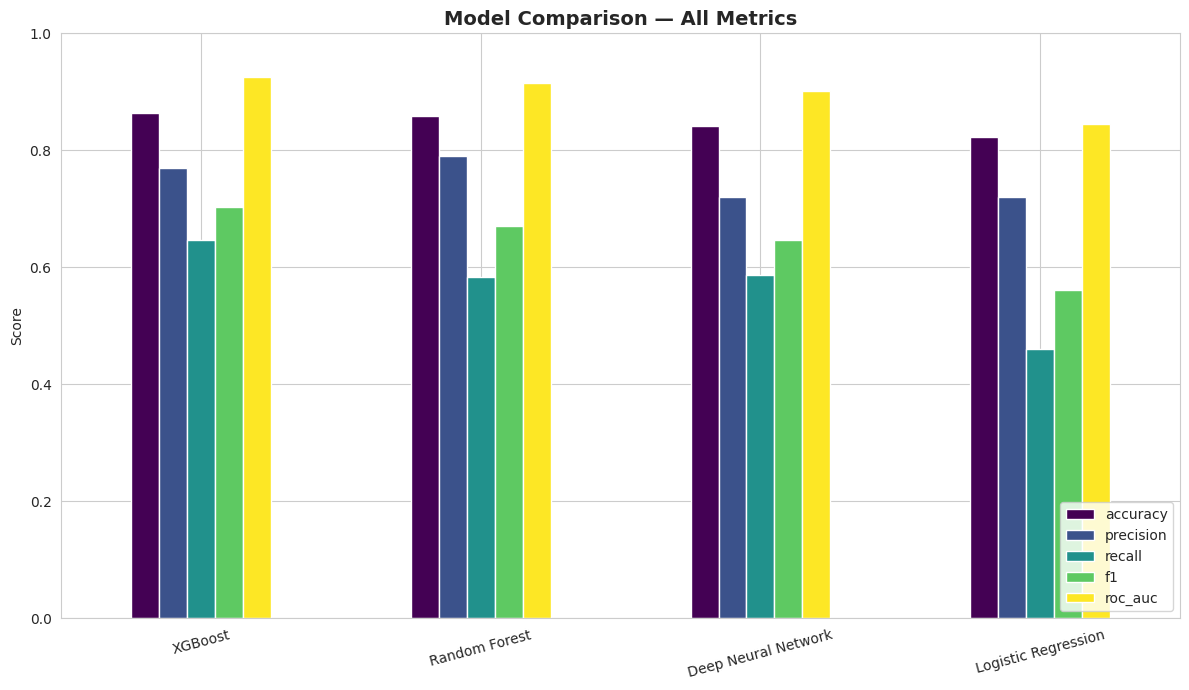

In [24]:

fig, ax = plt.subplots(figsize=(12, 7))
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.1 ROC Curves — All Models

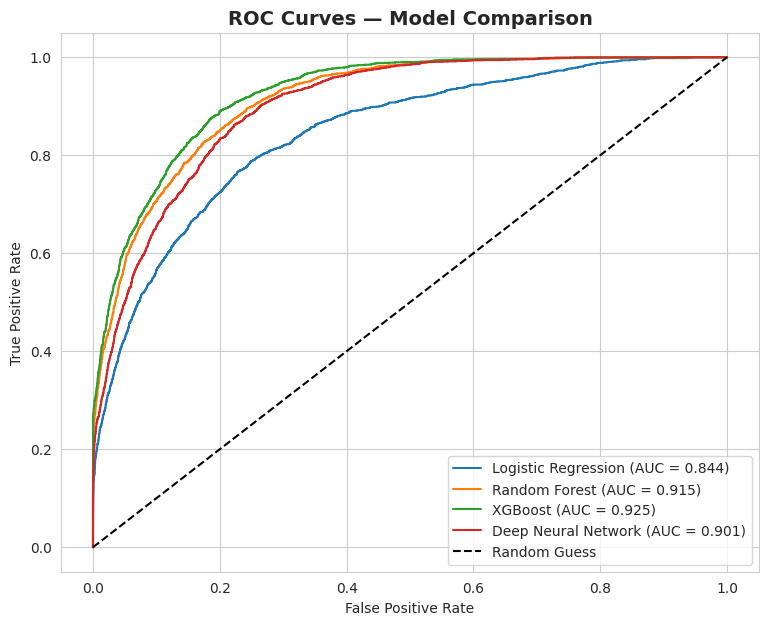

In [25]:

plt.figure(figsize=(9, 7))
for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf),
                      ('XGBoost', y_prob_xgb), ('Deep Neural Network', y_prob_dl)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('outputs/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.2 Confusion Matrices

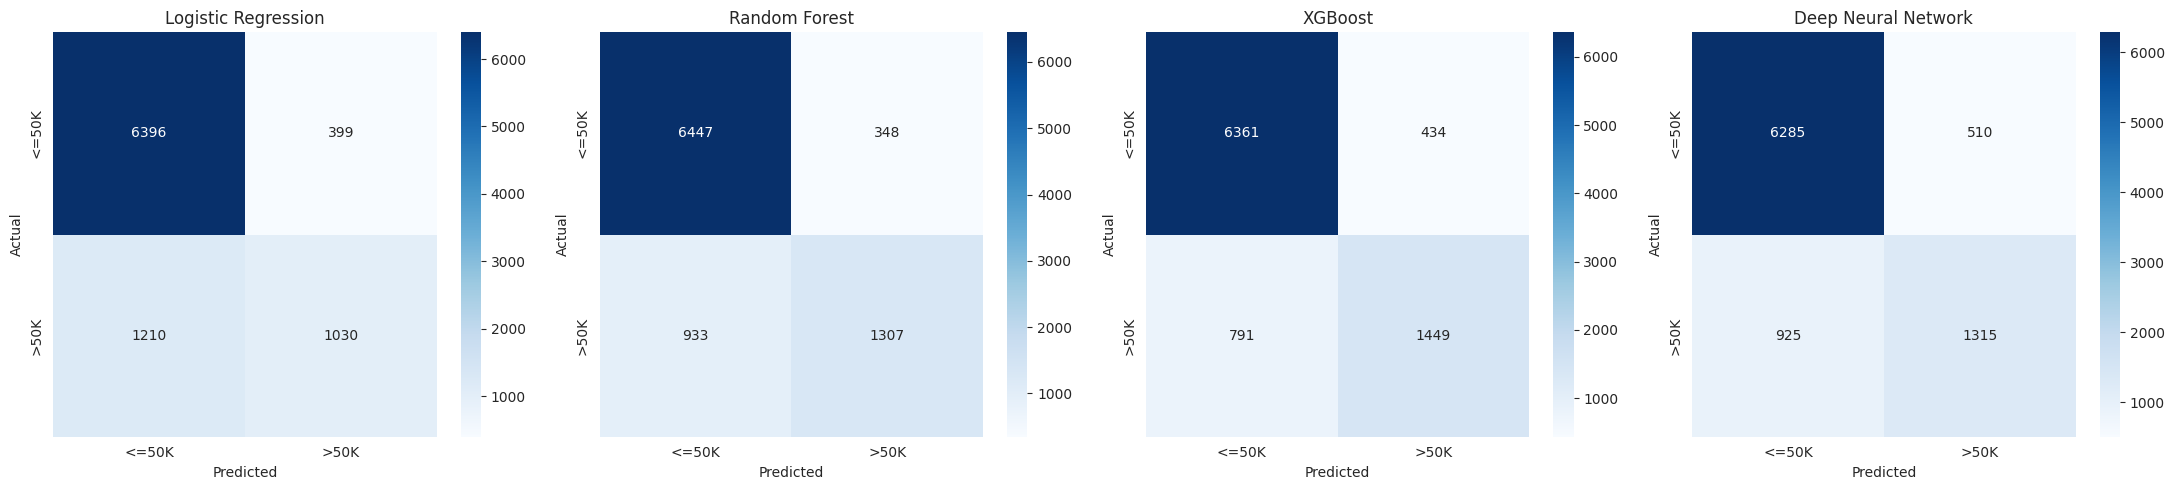

In [26]:

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
preds = [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf),
         ('XGBoost', y_pred_xgb), ('Deep Neural Network', y_pred_dl)]

for ax, (name, pred) in zip(axes, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Save Best Model + Preprocessing Objects (Production Artifacts)
We save the best classical ML model, the deep learning model, and all preprocessing
objects (scaler + encoders) needed to run this model in production (Streamlit app).

In [27]:

best_ml_name = results_df.drop('Deep Neural Network', errors='ignore').index[0]
print("Best classical ML model:", best_ml_name)

model_lookup = {'Logistic Regression': log_reg, 'Random Forest': rf, 'XGBoost': xgb}
best_ml_model = model_lookup[best_ml_name]

os.makedirs('models', exist_ok=True)

joblib.dump(best_ml_model, 'models/best_ml_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(encoders, 'models/label_encoders.pkl')
joblib.dump(target_le, 'models/target_encoder.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')

dl_model.save('models/dl_model.keras')

with open('models/results_summary.json', 'w') as f:
    json.dump(results, f, indent=4)

print("All models & preprocessing objects saved to /models")
print(os.listdir('models'))


Best classical ML model: XGBoost
All models & preprocessing objects saved to /models
['label_encoders.pkl', 'best_ml_model.pkl', 'feature_names.pkl', 'dl_model.keras', 'results_summary.json', 'scaler.pkl', 'target_encoder.pkl']


## 9. Production Prediction Check
Simulating a real production scenario: load the saved artifacts fresh (as a deployed
app would) and run predictions on brand-new, unseen sample inputs.

In [28]:

# Reload everything fresh — exactly as the Streamlit app will do
loaded_ml_model = joblib.load('models/best_ml_model.pkl')
loaded_dl_model = keras.models.load_model('models/dl_model.keras')
loaded_scaler = joblib.load('models/scaler.pkl')
loaded_encoders = joblib.load('models/label_encoders.pkl')
loaded_target_le = joblib.load('models/target_encoder.pkl')
loaded_feature_names = joblib.load('models/feature_names.pkl')

print("Artifacts reloaded successfully — simulating production environment.")


Artifacts reloaded successfully — simulating production environment.


In [29]:

def predict_income(sample: dict, model_type='ml'):
    """
    sample: dict with raw human-readable feature values
    model_type: 'ml' or 'dl'
    """
    row = pd.DataFrame([sample])
    for col, le in loaded_encoders.items():
        row[col] = le.transform(row[col].astype(str))
    row = row[loaded_feature_names]
    row_scaled = loaded_scaler.transform(row)

    if model_type == 'ml':
        prob = loaded_ml_model.predict_proba(row_scaled)[0][1]
    else:
        prob = float(loaded_dl_model.predict(row_scaled, verbose=0)[0][0])

    pred_class = loaded_target_le.inverse_transform([int(prob >= 0.5)])[0]
    return pred_class, prob

# Sample 1: Likely high income profile
sample_1 = {
    'age': 45, 'workclass': 'Private', 'fnlwgt': 150000, 'education': 'Masters',
    'education_num': 14, 'marital_status': 'Married-civ-spouse', 'occupation': 'Exec-managerial',
    'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital_gain': 5000,
    'capital_loss': 0, 'hours_per_week': 50, 'native_country': 'United-States'
}

# Sample 2: Likely low income profile
sample_2 = {
    'age': 22, 'workclass': 'Private', 'fnlwgt': 200000, 'education': 'HS-grad',
    'education_num': 9, 'marital_status': 'Never-married', 'occupation': 'Other-service',
    'relationship': 'Own-child', 'race': 'White', 'sex': 'Female', 'capital_gain': 0,
    'capital_loss': 0, 'hours_per_week': 25, 'native_country': 'United-States'
}

for name, sample in [('Sample 1 (Experienced Manager)', sample_1), ('Sample 2 (Young Entry-Level)', sample_2)]:
    pred_ml, prob_ml = predict_income(sample, 'ml')
    pred_dl, prob_dl = predict_income(sample, 'dl')
    print(f"--- {name} ---")
    print(f"  [{best_ml_name}] Prediction: {pred_ml}  (P(>50K) = {prob_ml:.3f})")
    print(f"  [Deep Learning] Prediction: {pred_dl}  (P(>50K) = {prob_dl:.3f})")
    print()


--- Sample 1 (Experienced Manager) ---
  [XGBoost] Prediction: >50K  (P(>50K) = 0.777)
  [Deep Learning] Prediction: >50K  (P(>50K) = 0.882)

--- Sample 2 (Young Entry-Level) ---
  [XGBoost] Prediction: <=50K  (P(>50K) = 0.000)
  [Deep Learning] Prediction: <=50K  (P(>50K) = 0.000)



## 10. Conclusion

- Cleaned & analyzed a real 45K+ row US Census income dataset with full EDA.
- Trained 3 classical ML models (Logistic Regression, Random Forest, XGBoost) and 1 Deep Neural Network.
- Compared all models on Accuracy, Precision, Recall, F1, and ROC-AUC.
- Saved the best model + DL model + all preprocessing objects as production artifacts.
- Verified production-readiness with a fresh reload + real prediction check on new samples.
- **Next step:** `app.py` Streamlit application for live interactive predictions (see accompanying file).
